# 07 — Cartonization (selección de caja)

> **Catálogo homogéneo `showcase_master_catalog.json`** — mismos SKUs P1–P5 en 3D-BPP, Container Loading y Single Container. Cada tipo usa una **instancia showcase** compleja donde el benchmark **diferencia** los algoritmos del grupo.

**Instancia:** `showcase_cartonization_instance.json` — pedido de **6 cubos P5** (20×20×20)
y catálogo de cajas **BOX_S / BOX_M / BOX_L**.

El problema: elegir **una caja** donde quepa todo el pedido.
El benchmark (perfil `box_selection`) compara 4 criterios de selección;
`largest_feasible_box` elige BOX_L (mucho espacio vacío) frente a las estrategias minimalistas (BOX_M).


In [1]:
# Configuración del entorno (ejecutar primero)
%matplotlib inline

import sys
from pathlib import Path
import matplotlib.pyplot as plt

_cwd = Path.cwd().resolve()
for _candidate in [_cwd, *_cwd.parents]:
    _nb = _candidate / "notebooks"
    if (_nb / "_shared" / "loaders.py").exists():
        if str(_nb) not in sys.path:
            sys.path.insert(0, str(_nb))
        break
else:
    raise RuntimeError("No se encontró notebooks/_shared. Abre el notebook desde packing-services/.")

from _shared.loaders import setup_paths
ROOT = setup_paths(_cwd)
from _shared import display, viz, runners

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print(f"Proyecto: {ROOT}")


Proyecto: /home/edmundo/packing-services


In [2]:
from _shared.loaders import load_showcase_instance, build_algorithm_execute_input
from packing_services.domain.models import Container

instance = load_showcase_instance('CARTONIZATION')
algo = 'smallest_feasible_box'
payload = build_algorithm_execute_input(algo)
print('═══ PROBLEMA: pedido + catálogo de cajas ═══')
display.show_problem_overview(instance)
print('Endpoint:', f'POST /algorithms/{algo}/execute')


═══ PROBLEMA: pedido + catálogo de cajas ═══


Catálogo de cajas candidatas:


Caja,Largo,Ancho,Alto,Peso máx,Volumen
BOX_S,40,30,25,15,30000
BOX_M,55,45,40,25,99000
BOX_L,70,55,60,40,231000


Catálogo de piezas (ítems):


Tipo,Largo,Ancho,Alto,Peso,Cantidad
P5,20,20,20,2,6


Restricciones activas: non_overlap, containment, allow_rotation, max_weight
Endpoint: POST /algorithms/smallest_feasible_box/execute


2026-07-13 12:46:42,993 | INFO    | packing_services.services.algorithm_execution_service | algorithm-execute name=smallest_feasible_box problem_type=CARTONIZATION request_id=showcase-carton-001


2026-07-13 12:46:42,994 | INFO    | packing_services.services.cartonization_service | cartonization request_id=showcase-carton-001 algorithm=smallest_feasible_box items=6 boxes=3


═══ SOLUCIÓN ═══


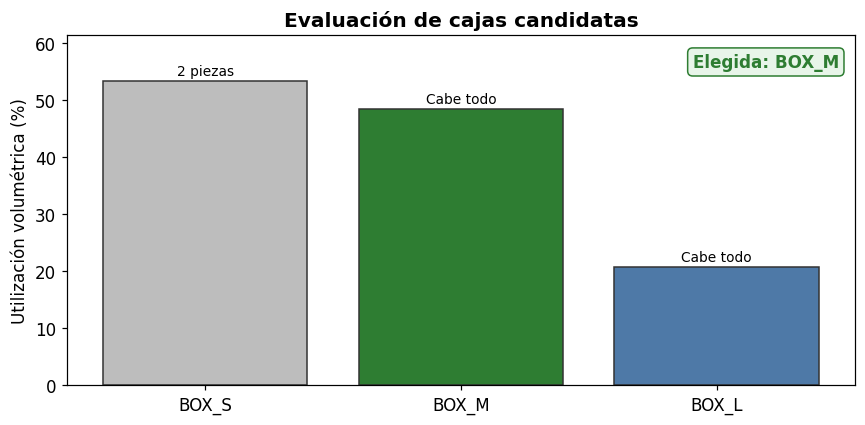

In [3]:
print('═══ SOLUCIÓN ═══')
result = runners.run_algorithm_execute(algo, payload)
solution = display.show_execute_result(result)
fig = viz.plot_box_catalog(result.cartonization.evaluated_boxes, result.cartonization.selected_box_id)
plt.show()


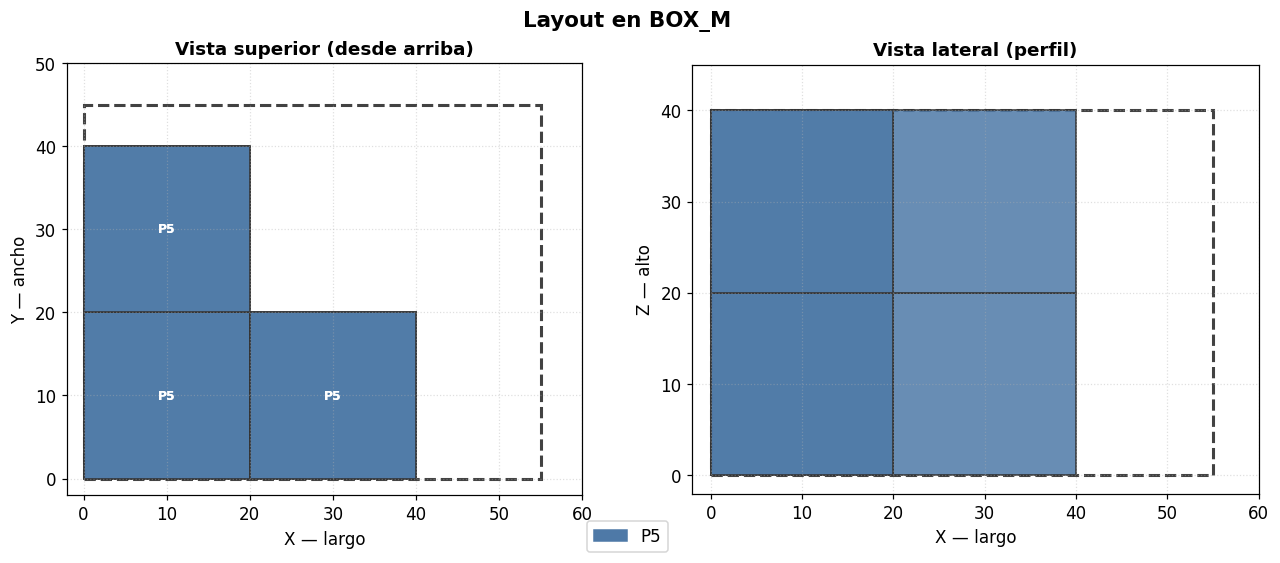

In [4]:
from packing_services.schemas.requests import BoxOption
box = next(BoxOption(**b) for b in payload['boxes'] if b['id'] == result.cartonization.selected_box_id)
container = box.to_container()
fig = viz.plot_container_views(solution, container, title=f'Layout en {result.cartonization.selected_box_id}')
plt.show()


═══ BENCHMARK HOMOGÉNEO (Cartonization) ═══
Motores comparables — Cartonization:


#,Algoritmo,Nombre,Opcional
1,smallest_feasible_box,Smallest Feasible Box,No
2,best_box_volume_utilization,Best Box by Volume Utilization,No
3,first_fit_box,First Fit Box (orden catálogo),No
4,largest_feasible_box,Largest Feasible Box,No
5,multi_box_cartonization,Multi-box Cartonization,No


2026-07-13 12:46:43,592 | INFO    | packing_services.services.cartonization_service | cartonization request_id=benchmark-carton-001 algorithm=smallest_feasible_box items=6 boxes=3


2026-07-13 12:46:43,599 | INFO    | packing_services.services.cartonization_service | cartonization request_id=benchmark-carton-001 algorithm=best_box_volume_utilization items=6 boxes=3


2026-07-13 12:46:43,609 | INFO    | packing_services.services.cartonization_service | cartonization request_id=benchmark-carton-001 algorithm=first_fit_box items=6 boxes=3


2026-07-13 12:46:43,616 | INFO    | packing_services.services.cartonization_service | cartonization request_id=benchmark-carton-001 algorithm=largest_feasible_box items=6 boxes=3


Nota: single-box → BOX_M (~49%) vs multi_box → varias cajas S/M
Benchmark — Cartonization


Posición,Algoritmo,Utilización,Empacados,Sin empacar,Válida,Tiempo (s),Caja elegida
1,first_fit_box,48.5%,6,0,Sí,0.0026,BOX_M
2,smallest_feasible_box,48.5%,6,0,Sí,0.0027,BOX_M
3,best_box_volume_utilization,48.5%,6,0,Sí,0.0029,BOX_M
4,largest_feasible_box,20.8%,6,0,Sí,0.0025,BOX_L


Ranking Cartonization: (1) válidas; (2) todos los ítems empacados; (3) mayor volume_utilization; (4) menor tiempo.


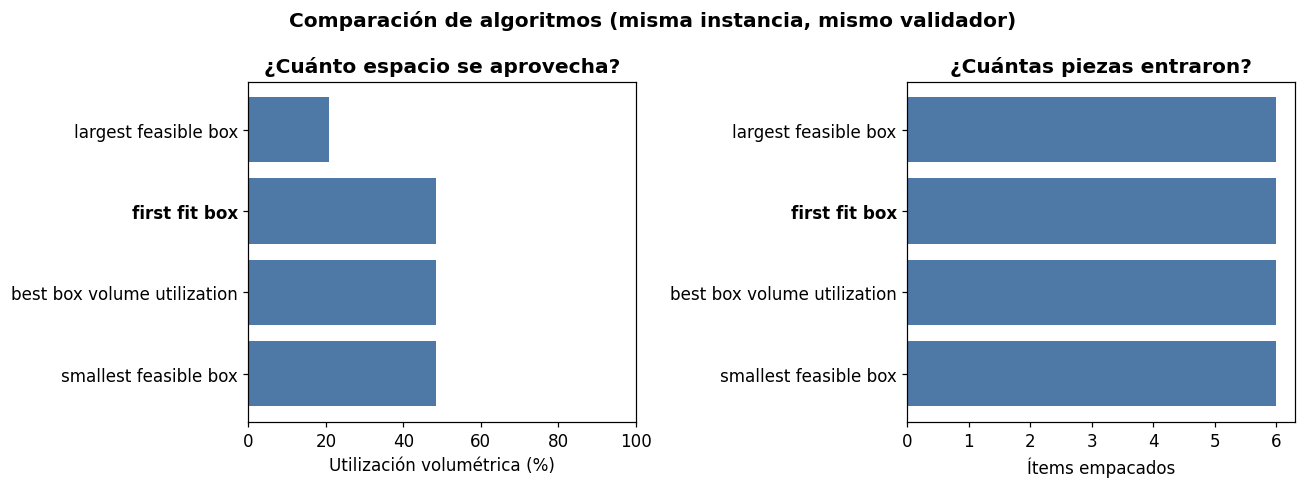

BenchmarkResponse(request_id='benchmark-carton-001', results=[BenchmarkEngineResult(engine='smallest_feasible_box', status='success', is_valid=True, metrics=Metrics(volume_utilization=0.484848, waste_volume=0.515152, containers_used=1, items_packed=6, items_unpacked=0, packed_volume=48000.0, unpacked_volume=0.0, total_item_volume=48000.0, loaded_weight=12.0, execution_time_seconds=0.002712, constraint_violations=0), validation_report=ValidationReport(is_valid=True, violations=[]), solution=PackingSolution(request_id='benchmark-carton-001', status=<SolutionStatus.SUCCESS: 'success'>, problem_type=<ProblemType.CARTONIZATION: 'CARTONIZATION'>, algorithm_name='smallest_feasible_box', packed_items=[PackedItem(item_id='P5#1', container_id='BOX_M', position=Point3D(x=0.0, y=0.0, z=0.0), orientation=Orientation(length=20.0, width=20.0, height=20.0), weight=2.0), PackedItem(item_id='P5#2', container_id='BOX_M', position=Point3D(x=0.0, y=0.0, z=20.0), orientation=Orientation(length=20.0, width=2

In [5]:
print('═══ BENCHMARK HOMOGÉNEO (Cartonization) ═══')
display.run_and_show_showcase_benchmark('CARTONIZATION', instance)


**Siguiente:** `08_catalogo_algoritmos_y_futuro.ipynb`
